<a href="https://colab.research.google.com/github/Hibashanti/Time-Series-Analysis/blob/main/Chicago_Crimes_Core.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Chicago Crime Data

- Author : Hiba Shanti

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [30]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
!pip install holidays
import holidays
import datetime as dt
from holidays import country_holidays


# Load the Data
- Integrating multiple years of Chicago Crime files into one dataset.  

In [4]:
folder_path = "/content/drive/MyDrive/Axsos Academy/AXSOSACADEMY-1/Time Series Data/Data/Data"
files = os.listdir(folder_path)

print(files)  # to confirm your files

['Chicago-Crime_2001.csv', 'Chicago-Crime_2002.csv', 'Chicago-Crime_2003.csv', 'Chicago-Crime_2004.csv', 'Chicago-Crime_2005.csv', 'Chicago-Crime_2006.csv', 'Chicago-Crime_2007.csv', 'Chicago-Crime_2009.csv', 'Chicago-Crime_2008.csv', 'Chicago-Crime_2010.csv', 'Chicago-Crime_2012.csv', 'Chicago-Crime_2011.csv', 'Chicago-Crime_2013.csv', 'Chicago-Crime_2015.csv', 'Chicago-Crime_2014.csv', 'Chicago-Crime_2016.csv', 'Chicago-Crime_2017.csv', 'Chicago-Crime_2020.csv', 'Chicago-Crime_2019.csv', 'Chicago-Crime_2018.csv', 'Chicago-Crime_2021.csv', 'Chicago-Crime_2022.csv', 'README.txt', 'example_time_series.csv']


In [5]:
df_list = []

for file in files:
    if file.endswith('.csv'):
        file_path = os.path.join(folder_path, file)
        df_temp = pd.read_csv(file_path)
        df_list.append(df_temp)

# Combine all dataframes
df = pd.concat(df_list, ignore_index=True)

print(df.shape)
df.head()

(7713309, 18)


,ID,Date,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Latitude,Longitude,ts_1,ts_2,ts_3,ts_4,ts_5,ts_6
0,1326041.0,01/01/2001 01:00:00 AM,BATTERY,SIMPLE,RESIDENCE,False,False,1624.0,16.0,NaN,41.957850,-87.749185,NaN,NaN,NaN,NaN,NaN,NaN
1,1319931.0,01/01/2001 01:00:00 PM,BATTERY,SIMPLE,RESIDENCE,False,True,825.0,8.0,NaN,41.783892,-87.684841,NaN,NaN,NaN,NaN,NaN,NaN
2,1324743.0,01/01/2001 01:00:00 PM,GAMBLING,ILLEGAL ILL LOTTERY,STREET,True,False,313.0,3.0,NaN,41.780412,-87.611970,NaN,NaN,NaN,NaN,NaN,NaN
3,1310717.0,01/01/2001 01:00:00 AM,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,2424.0,24.0,NaN,42.012391,-87.678032,NaN,NaN,NaN,NaN,NaN,NaN
4,1318099.0,01/01/2001 01:00:00 AM,BATTERY,SIMPLE,RESIDENCE PORCH/HALLWAY,False,True,214.0,2.0,NaN,41.819538,-87.620020,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Convert the datt column to a datetime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce', format='mixed')
df=df.set_index('Date')
df=df.drop(columns="ID")
df.head()

,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Latitude,Longitude,ts_1,ts_2,ts_3,ts_4,ts_5,ts_6
Date,,,,,,,,,,,,,,,,
2001-01-01 01:00:00,BATTERY,SIMPLE,RESIDENCE,False,False,1624.0,16.0,NaN,41.957850,-87.749185,NaN,NaN,NaN,NaN,NaN,NaN
2001-01-01 13:00:00,BATTERY,SIMPLE,RESIDENCE,False,True,825.0,8.0,NaN,41.783892,-87.684841,NaN,NaN,NaN,NaN,NaN,NaN
2001-01-01 13:00:00,GAMBLING,ILLEGAL ILL LOTTERY,STREET,True,False,313.0,3.0,NaN,41.780412,-87.611970,NaN,NaN,NaN,NaN,NaN,NaN
2001-01-01 01:00:00,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,2424.0,24.0,NaN,42.012391,-87.678032,NaN,NaN,NaN,NaN,NaN,NaN
2001-01-01 01:00:00,BATTERY,SIMPLE,RESIDENCE PORCH/HALLWAY,False,True,214.0,2.0,NaN,41.819538,-87.620020,NaN,NaN,NaN,NaN,NaN,NaN


## Topic 1) Comparing Police Districts


##### Which district had the most crimes in 2022?


In [7]:
#1- Calculate the number of crimes for each district yearly
crimes=df.groupby("District").resample("YE").size()
crimes

District  Date      
1.0       2001-12-31    14861
          2002-12-31    17974
          2003-12-31    17571
          2004-12-31    17579
          2005-12-31    17700
                        ...  
31.0      2018-12-31       11
          2019-12-31        7
          2020-12-31        4
          2021-12-31       15
          2022-12-31       15
Length: 507, dtype: int64

In [8]:
# 2- Get the crimes for all discrits in 2022
crimes_22=crimes.loc[(slice (None), "2022")]
crimes_22

,0
District,
1.0,13044
2.0,11793
3.0,11937
4.0,13931
5.0,9773
6.0,14694
7.0,10319
8.0,14805
9.0,10376


In [9]:
# Defining Districs with most crimes in 2022
most_crimes_22_number=crimes_22.max()
most_crimes_22_name=crimes_22.idxmax()
print(f"max crime number in 2022 is {most_crimes_22_number},in {most_crimes_22_name} discrit")

max crime number in 2022 is 14805,in 8.0 discrit


#Which District had the least number of crimes?


In [10]:
# Defining Districs with most crimes in 2022

least_crimes_22_number=crimes_22.min()
least_crimes_22_name=crimes_22.idxmin()
print(f"min crime number in 2022 is {least_crimes_22_number},in {least_crimes_22_name} discrit")


min crime number in 2022 is 15,in 31.0 discrit


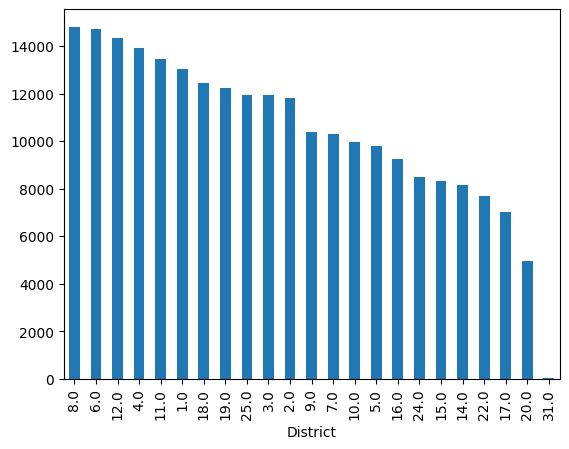

In [11]:
# Visualize the ordered discrits in terms of crime numbers in 2022.
crimes_order=crimes_22.sort_values(ascending=False)
ax=crimes_order.plot(kind="bar")

## Topic 2) Crimes Across the Years:

Text(0, 0.5, 'Number of Crimes')

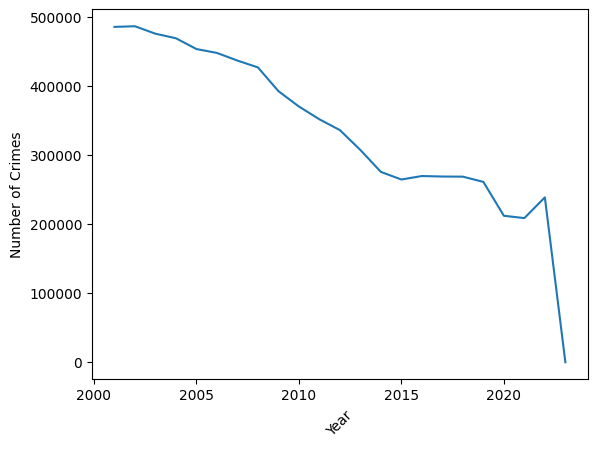

In [12]:
#Is the total number of crimes increasing or decreasing across the years
crimes_trend=df.resample("YE").size()

fig,ax=plt.subplots()
sns.lineplot(x=crimes_trend.index.year, y=crimes_trend.values,ax=ax);
ax.set_xlabel("Year",rotation=45)
ax.set_ylabel("Number of Crimes")


#Chicago crimes have generally decreased over time,with a slight fluctuation.
#The sharp drop in crimes after 2023 is due to incomplete or missing data for the most recent year, not an actual decline.


In [13]:
#Are there any individual crimes that are doing the opposite (e.g., decreasing when overall crime is increasing or vice-versa)?
# 1- define the individual crimes during the years
time_bucket=pd.Grouper(freq="YE")
individual_crimes=df.groupby(["Primary Type", time_bucket]).size()

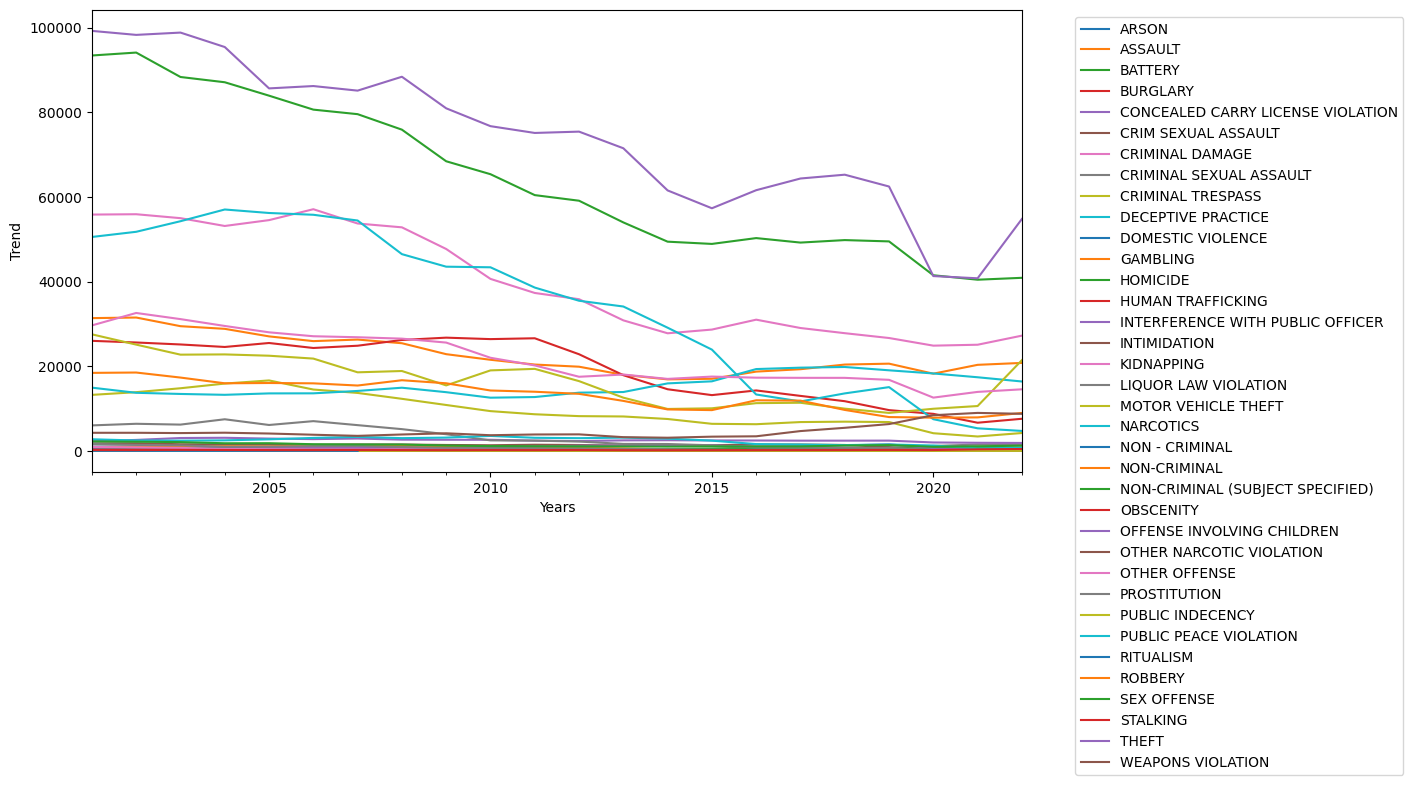

In [14]:
# Visualize the individual crimes during the years
unstacked=individual_crimes.unstack(level=0)
individual_trend=unstacked.plot(figsize=(12,6))
individual_trend.set_xlabel("Years")
individual_trend.set_ylabel("Trend")
plt.legend(bbox_to_anchor=(1.05,1),loc="upper left");


# Topic 3) Comparing AM vs. PM Rush Hour:


- Are crimes more common during AM rush hour or PM rush hour?
  - You can consider any crime that occurred between 7 AM - 10 AM as AM rush hour
  - You can consider any crime that occurred between 4 - 7 PM as PM rush hour.

In [15]:
# 1-Define new column for the Hours in the dataset
df["Hour"]=df.index.hour
df["Hour"]

,Hour
Date,
2001-01-01 01:00:00,1
2001-01-01 13:00:00,13
2001-01-01 13:00:00,13
2001-01-01 01:00:00,1
2001-01-01 01:00:00,1
...,...
2023-10-01 00:00:00,0
2023-10-08 00:00:00,0
2023-10-15 00:00:00,0


In [16]:
# 2-Identify each rushing hour group
am_rush=df[(df["Hour"] >= 7) & (df["Hour"]<= 10)]
pm_rush=df[(df["Hour"] >= 16) & (df["Hour"]<=19)]

In [17]:
# 3-Address the length of each group
am_count=len(am_rush)
pm_count=len(pm_rush)

print(f'The Number of crimes in AM rush hour = {am_count}, and in PM rush hour = {pm_count}')

The Number of crimes in AM rush hour = 1097647, and in PM rush hour = 1641051


- Crimes are more common to occure during PM rush hour with a total number of 1,641,051 compared with a total of 1,097,647 in AM rush hour.


In [18]:
#What are the top 5 most common crimes during AM rush hour? What are the top 5 most common crimes during PM rush hour?
top_5_am=am_rush["Primary Type"].value_counts()
top_5_am.head(5)

,count
Primary Type,
THEFT,260759
BATTERY,158475
CRIMINAL DAMAGE,109089
BURGLARY,96219
OTHER OFFENSE,89870


In [19]:
#What are the top 5 most common crimes during PM rush hour?
top_5_pm=pm_rush["Primary Type"].value_counts()
top_5_pm.head(5)

,count
Primary Type,
THEFT,379122
BATTERY,288003
CRIMINAL DAMAGE,183423
NARCOTICS,164754
ASSAULT,118179


In [20]:
#Are Motor Vehicle Thefts more common during AM rush hour or PM Rush Hour?
# specify the Motor Vehicle Thefts
mvt_am=am_rush[am_rush["Primary Type"]== "MOTOR VEHICLE THEFT"]
mvt_pm=pm_rush[pm_rush["Primary Type"]== "MOTOR VEHICLE THEFT"]

In [21]:
# Define the length of each period
mvt_am_count=len(mvt_am)
mvt_pm_count=len(mvt_pm)
print(f' number of Motor Vehicle Thefts in AM rush hour= {mvt_am_count},number of Motor Vehicle Thefts in PM rush hour= {mvt_pm_count}')

 number of Motor Vehicle Thefts in AM rush hour= 54035,number of Motor Vehicle Thefts in PM rush hour= 74678


- The number of Motor Vehicle Thefts is more common in the PM rush hour.

 # 4) Comparing Months:


In [22]:
# Adding a Month column to the dataset
df["Month"]=df.index.month
df["Month"]

,Month
Date,
2001-01-01 01:00:00,1
2001-01-01 13:00:00,1
2001-01-01 13:00:00,1
2001-01-01 01:00:00,1
2001-01-01 01:00:00,1
...,...
2023-10-01 00:00:00,10
2023-10-08 00:00:00,10
2023-10-15 00:00:00,10


In [23]:
# What months have the most crime? What months have the least?
monthly_count=df["Month"].value_counts()
most_month=monthly_count.idxmax()
least_month=monthly_count.idxmin()
print(f'the months with the most crime is {most_month}, and the month with the least is {least_month} ')

the months with the most crime is 7, and the month with the least is 2 


In [24]:
#Are there any individual crimes that do not follow this pattern? If so, which crimes?
monthly_crimes=df.groupby(["Primary Type", "Month"]).size()

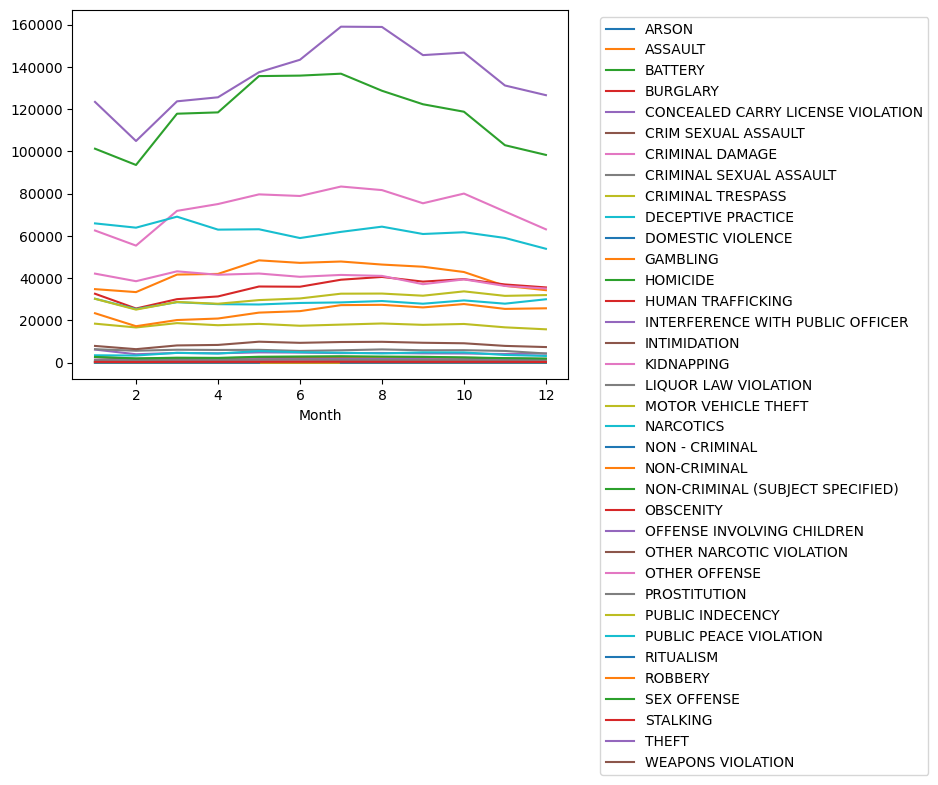

In [25]:
# Visualize the data for each crime during the months
unstacked=monthly_crimes.unstack(level=0)
unstacked.plot()
plt.legend(bbox_to_anchor=(1.05,1),loc="upper left");

In [26]:
# to find the peak for each month,
peak_per_month=unstacked.idxmax()
peak_per_month

,0
Primary Type,
ARSON,7
ASSAULT,5
BATTERY,7
BURGLARY,8
CONCEALED CARRY LICENSE VIOLATION,9
CRIM SEXUAL ASSAULT,7
CRIMINAL DAMAGE,7
CRIMINAL SEXUAL ASSAULT,7
CRIMINAL TRESPASS,3


In [27]:
# to find the least point for each month,
least_per_month=unstacked.idxmin()
least_per_month

,0
Primary Type,
ARSON,2
ASSAULT,2
BATTERY,2
BURGLARY,2
CONCEALED CARRY LICENSE VIOLATION,1
CRIM SEXUAL ASSAULT,12
CRIMINAL DAMAGE,2
CRIMINAL SEXUAL ASSAULT,2
CRIMINAL TRESPASS,12


5) Comparing Holidays:

In [43]:
# Define the holidays in Chicago
Chicago_Holiday=country_holidays("US", subdiv="IL") # Chicago is located in Illinois
Chicago_Holiday

holidays.country_holidays('US', subdiv='IL')

In [47]:
#Get Checago holidays in a column
df["Holiday"]= [Chicago_Holiday.get(day)for day in df.index]
df["Holiday"]

,Holiday
Date,
2001-01-01 01:00:00,New Year's Day
2001-01-01 13:00:00,New Year's Day
2001-01-01 13:00:00,New Year's Day
2001-01-01 01:00:00,New Year's Day
2001-01-01 01:00:00,New Year's Day
...,...
2023-10-01 00:00:00,None
2023-10-08 00:00:00,None
2023-10-15 00:00:00,None


In [57]:
#What are the top 3 holidays with the largest number of crimes?
df["Holiday"].value_counts(ascending=False)


,count
Holiday,
New Year's Day,32726
Independence Day,22673
Labor Day,22164
Memorial Day,21125
Columbus Day,20920
Veterans Day,20418
Casimir Pulaski Day,19128
Lincoln's Birthday,18166
Martin Luther King Jr. Day,17916


In [94]:
holidays_name=["New Year's Day","Independence Day", "Labor Day"]
top_3=df[df["Holiday"].isin(holidays_name)]
for holiday in holidays_name :
   holiday_count=top_3[top_3["Holiday"]==holiday]
   top_5_crimes=holiday_count["Primary Type"].value_counts().head(5)
   print(f'{holiday},has the following 5 crimes{top_5_crimes}')



New Year's Day,has the following 5 crimesPrimary Type
THEFT                         6845
BATTERY                       6043
CRIMINAL DAMAGE               3236
DECEPTIVE PRACTICE            2934
OFFENSE INVOLVING CHILDREN    2380
Name: count, dtype: int64
Independence Day,has the following 5 crimesPrimary Type
BATTERY            5805
THEFT              4074
CRIMINAL DAMAGE    3309
ASSAULT            1547
NARCOTICS          1522
Name: count, dtype: int64
Labor Day,has the following 5 crimesPrimary Type
BATTERY            4607
THEFT              4520
CRIMINAL DAMAGE    2475
NARCOTICS          2078
ASSAULT            1525
Name: count, dtype: int64
